# Building makemore Part 3: Activations & Gradients, BatchNorm


https://www.youtube.com/watch?v=P6sfmUTpUmc&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=6

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open("names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length

def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0]* block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Initialization Problems of our Previous Model

1. When the probabilites are uniform, we have a loss of $-\log(1/27) \approx 3.29$, compared to random initialization loss of $\sim 27$. This is because the model has large weights (amplified by the softmax), making it confidently predicting wrong letters. This is why we get a hockey stick loss curve, as the training is spent squashing down the weights.

Then by symmetry, we would want our initial predicted outputs, or logits, to be near $0$. This optimizes the training time by removing the squashing down of the weights.

 - `logits = h @ W2 + b2`. 
     -  Because we `logits` to be small, it is a good idea to set `b2 = 0`.
      - We can also set `W2` to something small. It is not a good idea to set it to zero, so we multiply it by $0.01$ so it has some entropy, and so it is used for symmetry breaking.

2. $\tanh$ destroying gradient
 - tanh is a squashing function. It takes arbitrary numbers and squashes them to a range of $[-1, 1]$. For values in the range of $1$ to $-1$, since the gradient is defined as $1-\tanh^2$, the gradient is very small, so the weights will not update.

We can visualize the distribution of $h$ to get a better idea of what is happening.

In [6]:
# MLP revisited
n_embd = 10 # dimension of character embeddings vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # total number of parameters
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(1):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

11897
      0/ 200000 loss: 3.3221


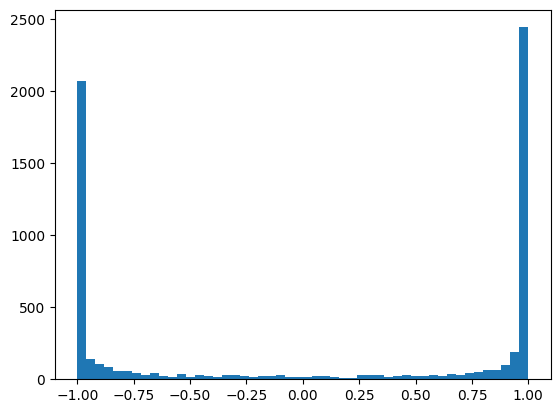

In [7]:
plt.hist(h.view(-1).tolist(), 50);

We can see that most values take on a value of $-1$ and $1$, so this $\tanh$ is very active. We can see why this is by looking at the preactivation of the tanh function.

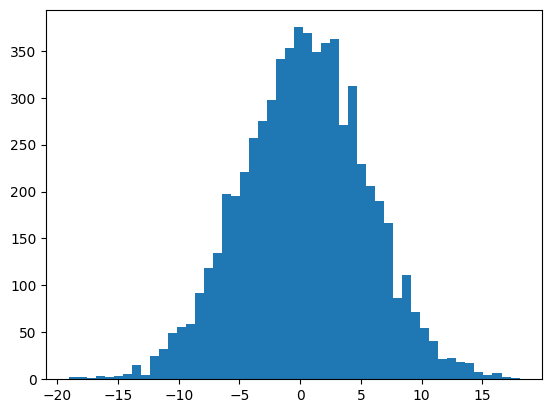

In [8]:
plt.hist(hpreact.view(-1).tolist(), 50);

We can see that this preactivation is very broad, and most of it will be squished to $-1$ and $1$.

To show why this is bad, here is the `tanh` function as defined in our micrograd:
```py
def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1-t**2) * out.grad
            
        out._backward = _backward
        
        return out
```
If the value outputted of $\tanh x =t$ is close to $1$ or $-1$, then $1-t^2$ will be close to 0, effectively killing the gradient and stopping `out.grad` from backpropagating.

Intuitively, if the $\tanh$ of a value (weights and biases) is close to $1$, it is at the tail of the $\tanh$, so changing the value won't change the activation too much, as it is in a flat region. This will result in no impact in the loss.

If $t=0$, the gradient is passed through and the neuron is unactivated. The closer it is to $1$ or $-1$, the more that it is being squished, and the less the gradient is passed through. The gradient flowing through $\tanh$ can only ever decrease, and it is decreased proportional to how close you are to the tails.

We can see how often the neurons are in a flat region by viewing a heatmap of the activations.

If a square is white, then the activation is close to $1$ or $-1$, or otherwise it is black.

We would be in trouble if there was an entire column of white, as that would mean we have a "dead neuron". This could be a `tanh` neuron where the initialization of the weights and the biases could be such that no single example ever activates the `tanh` in the active part of the `tanh`. If all the examples lead to the flat region, the neuron will never learn.


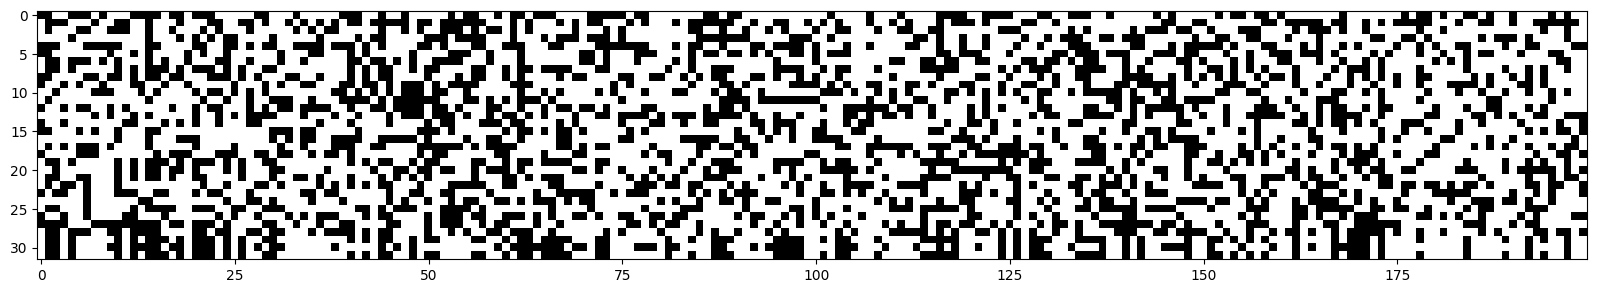

In [9]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In this case, there are no white columns, so some gradients will flow through and the neruon will learn.

For `tanh`, a neuron is dead if no matter the inputs from your dataset, it always fires at $1$ or $-1$. It will not learn as the gradients will be zeroed out. 

This is true for a lot of other non-linearities for neural networks:

![activation function](images/activation_functions.png)

Sigmoid will have the same problem as it is a squishing function like `tanh`.

ReLU will also have the same problem as it squashes negative values, so the gradient will be set to $0$ if the value is negative, so it will never learn. 

- This can sometimes during initialization, as by chance, some neurons will be dead.
- It can also happen during optimization. If you have too high of a learning rate, sometimes you have neurons that get too high of a gradient, so they get knocked off the data manifold, so from then on, no examples ever activate that neuron.

Leaky ReLU doesn't suffer from it as much as it doesn't have a flat region.
ELU might suffer from the issue as it has flat parts.


Since there is no column of white, we may be okay and the network may optimize. However, it is not optimal as the network has many non-learning activations, which is something you might now want during optimization.

To fix this, we need to somehow reduce `hpreact = embcat @ W1 + b1`. We want the preactivation to be closer to $0$, so we can reduce the values of `W1` and `b1`.

In [10]:
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01

In practice, setting it to a small number instead of $0$ as it can provide a bit of variation and diversity in the original initialization of the `tanh` neurons and can help optimization a little bit in practice.

Fixing this precisely:

We look at the following example:
Here, $x$ and $w$ are uniform gaussians with a standard deviation of 1.

By taking $y= x@ w$, we take samples from the uniform gaussians. Since we add multiple products of two samples between the gaussians (10 in this case), the standard deviation is going to be increased (i'm gonna read a statistics book)

It turns out the way to make $y$ have a std of 1 is to divide $w$ by the square root of the fan-in. 

tensor(-0.0046) tensor(1.0096)
tensor(-0.0001) tensor(1.0170)


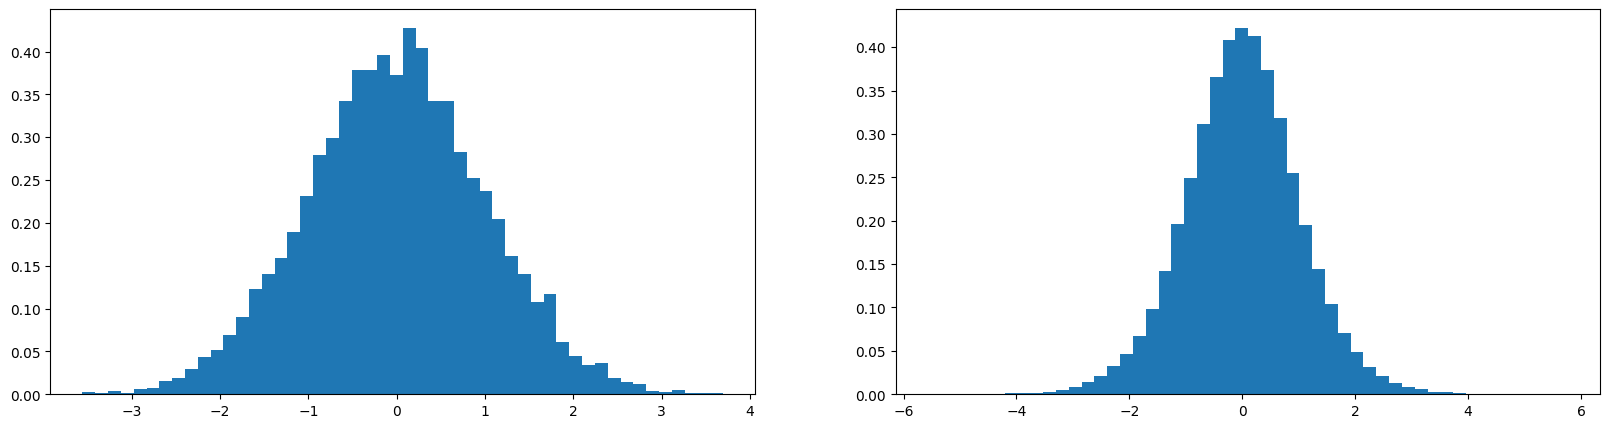

In [11]:
x = torch.randn(1000, 10) # uniform gaussian
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5));
plt.subplot(121);
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122);
plt.hist(y.view(-1).tolist(), 50, density=True);

Kaiming Paper: 
https://pytorch.org/docs/stable/nn.init.html
 - This is the most common way to initialize a network
 - Normalizing the activations vs normalizing the gradients doesn't matter too much, so people usually leave it as "fan-in"
 - The gain is for normalizing post activation. 
      - For Relu, it is $\sqrt{2}$ because the negative values are clamped.
      - For tanh, since the values are squished, a gain of $\frac{5}{3}$ is used to counteract the squishing of the function
      - For linear, it is kept as $1$ as the function doesn't affect the std.

We can calculate this manually for our network.

The fan-in is the number of samples taken from the multiplied distribution, which is `n_embd * block_size`. This is because we get our context size (`block_size`), get the embeddings for each of them, and then concat them.

In [12]:
(5/3) / ((n_embd*block_size)**0.5)

0.3042903097250923

Better initialization results:

In [13]:
# MLP revisited
n_embd = 10 # dimension of character embeddings vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) 
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3) / ((n_embd*block_size)**0.5) # * 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # total number of parameters
for p in parameters:
    p.requires_grad = True

11897


In [14]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad
        
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break

      0/ 200000 loss: 3.3179


With these fixes, we can see now that the initialization loss and neuron activation are fine.

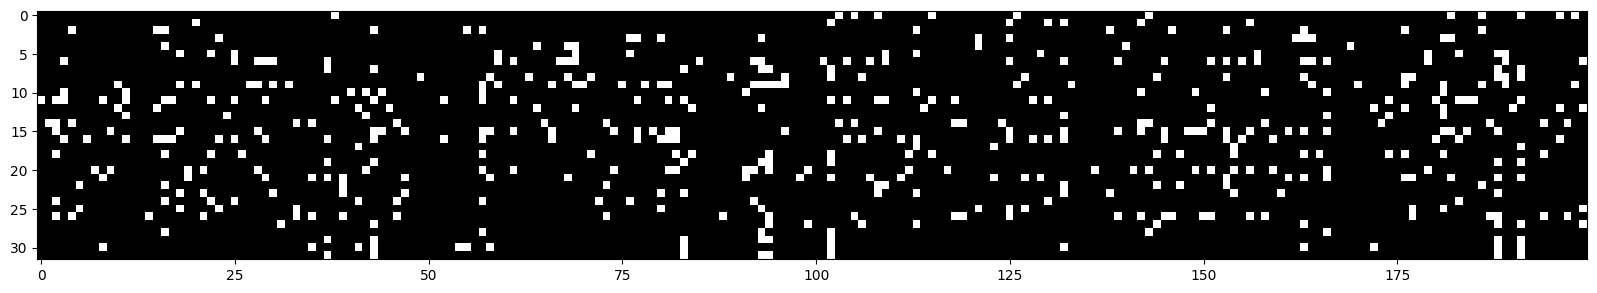

In [15]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# white if true, black if false
# if an entire column is white, then the neuron is dead

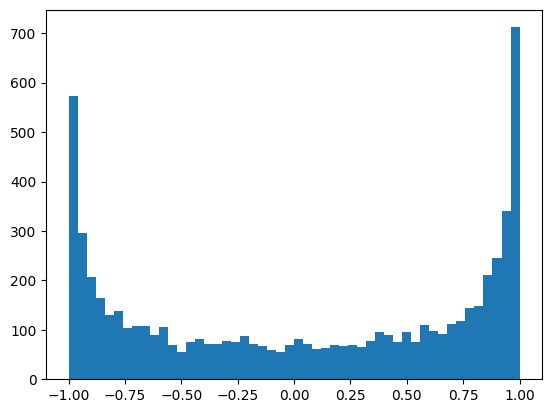

In [16]:
plt.hist(h.view(-1).tolist(), 50);

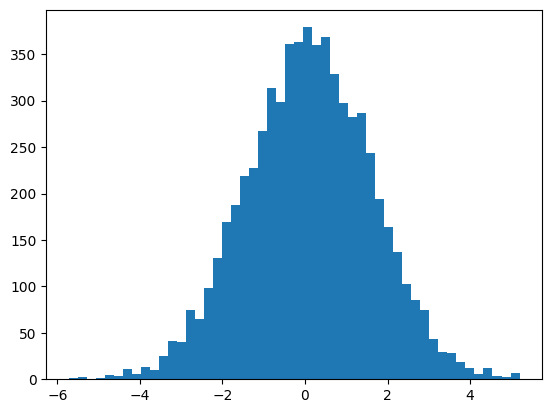

In [17]:
plt.hist(hpreact.view(-1).tolist(), 50);

Full Training:

In [18]:
# MLP revisited
n_embd = 10  # dimension of character embeddings vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / ((n_embd * block_size) ** 0.5)  # * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))  # total number of parameters
for p in parameters:
    p.requires_grad = True


11897


In [19]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000 loss: 3.3179
  10000/ 200000 loss: 2.1910
  20000/ 200000 loss: 2.3270
  30000/ 200000 loss: 2.5396
  40000/ 200000 loss: 1.9468
  50000/ 200000 loss: 2.3331
  60000/ 200000 loss: 2.3852
  70000/ 200000 loss: 2.1173
  80000/ 200000 loss: 2.3159
  90000/ 200000 loss: 2.2010
 100000/ 200000 loss: 1.8591
 110000/ 200000 loss: 2.0881
 120000/ 200000 loss: 1.9389
 130000/ 200000 loss: 2.3913
 140000/ 200000 loss: 2.0949
 150000/ 200000 loss: 2.1458
 160000/ 200000 loss: 1.7824
 170000/ 200000 loss: 1.7249
 180000/ 200000 loss: 1.9751
 190000/ 200000 loss: 1.8614


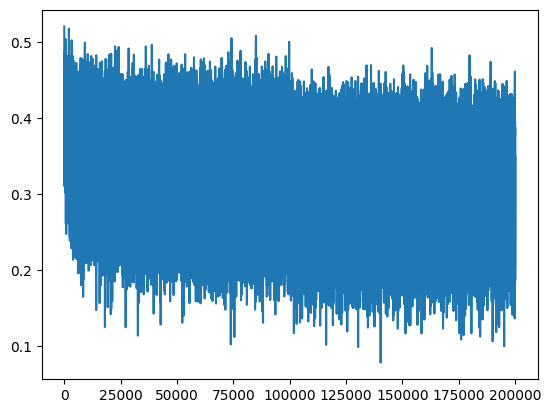

In [20]:
plt.plot(lossi)

In [21]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size*n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0376641750335693
val 2.106989622116089


We can see that the training is better because a lot less time is spent squishing down the function and more neurons can change their gradients.

Sampling from the model:

In [22]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with ...
    while True:
        # forward pass into the neural net
        emb = C[torch.tensor(context)]  # (1, block_size, n_embd)
        h = torch.tanh(emb.view(-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=0)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # convert indices back to characters


mora.
mayah.
see.
madhayla.
ren.
ruthndraeg.
adelyn.
elin.
shi.
jen.
eden.
est.
aaraelyzion.
kamin.
shuberlyni.
jest.
jair.
jeniqueterian.
brence.
ryyah.


Note: In the video, he uses `torch.tensor([context])` instead of `torch.tensor(context)`, probably to make sure that it is a matrix instead of a singular array. 

Due to broadcasting, we can probably remove the extra dimension (unsure about performance). Here is my simplified version of the code:

In [23]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0]*block_size # initialize with ...
    while True:
        # forward pass into the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # convert indices back to characters

mora.
mayah.
see.
madhayla.
ren.
ruthndraeg.
adelyn.
elin.
shi.
jen.
eden.
est.
aaraelyzion.
kamin.
shuberlyni.
jest.
jair.
jeniqueterian.
brence.
ryyah.


 The precise setting of initializations is not so important today because of some modern innovations.

## Batch Normalization

Batch Normalization allows us to train deep neural networks more reliably.

In `hpreact`, we don't want it to be too small, or else the `tanh` won't do anything. We also don't want it to be too large, or else the `tanh` will be saturated. We want it to be roughly gaussian at initialization.

The idea of Batch Normalization just states, why not just take the hidden states and normalize it to be Gaussian?

We want them to be Gaussian, but only at initialization. We don't want them to be forced to be always Gaussian, because sometimes we want them to be diffuse or more trigger-happy. We want the distribution to move around and let backpropagation figure that out.

This is the "Scale and shift" step of Batch Normalization. We normalize the hidden states per neuron to be Gaussian over the batch by scaling and shifting it.

It easy to add batch normalization layers throughout the neural net. Usually for every linear layer, a batch normalization is added to control the scale of the activations, and we don't need to be perfect about the initialization distribution.

The problem now is that the neural net is also a function of the examples that happened to come in the batch.

Since the mean and std can be different for each example, there will be a jitter on `h` and `logits` per batch.

In a strange way, this is good as a side effect. This is because this jitter acts like a regularizer, as it is padding out the input examples and adding a little of entropy. It is like a data augmentation, so by introducing the noise, it makes it harder for the neural net to overfit.

This benefit has made it harder to remove the use of batch normalization. No one likes the fact that batch normalization is coupled mathematically with the examples, and it can lead to a lot of bugs. People have tried to depreciate the use of Batch normalization and move to other techniques that don't couple the examples of a batch. Examples: Layer normalization, instance normalization, and group normalization.


We note that `b1` is completely useless now as it gets removed during normalization.

In [29]:
n_embd = 10  # dimension of character embeddings vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / ((n_embd * block_size) ** 0.5)  # * 0.2
#b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # total number of parameters
for p in parameters:
    p.requires_grad = True


12097


In [30]:
hpreact.shape

torch.Size([32, 200])

In [31]:
hpreact.mean(0, keepdim = True).shape

torch.Size([1, 200])

In [32]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [33]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    
    # Batch Norm layer
    # ------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    # running mean/std
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        # the 0.001 is the momentum in pytorch. If you have large batch sizes, then the mean and std won't change much, so you can use higher momentum
        # for batch size as small as 32, the value changes a lot. setting it to 0.1 makes it harder to settle, so the mean and std may change a lot, which is bad
    # ------------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000 loss: 3.3239
  10000/ 200000 loss: 2.0322
  20000/ 200000 loss: 2.5675
  30000/ 200000 loss: 2.0125
  40000/ 200000 loss: 2.2446
  50000/ 200000 loss: 1.8897
  60000/ 200000 loss: 2.0785
  70000/ 200000 loss: 2.3681
  80000/ 200000 loss: 2.2918
  90000/ 200000 loss: 2.0238
 100000/ 200000 loss: 2.3673
 110000/ 200000 loss: 2.3132
 120000/ 200000 loss: 1.6414
 130000/ 200000 loss: 1.9311
 140000/ 200000 loss: 2.2231
 150000/ 200000 loss: 2.0027
 160000/ 200000 loss: 2.0997
 170000/ 200000 loss: 2.4949
 180000/ 200000 loss: 2.0199
 190000/ 200000 loss: 2.1707


We'd like to deploy our neural net, but how do we do this for a single example when our neural net estimates the statistics as a batch?

The proposal in the Batch normalization paper is to have a step after training that calculates and sets Batch norm mean and standard deviation a single time to calibrate the batch norm statistics

In [34]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

However, estimating the mean and std as a second stage might be inefficient.

Another idea that the paper introduced is to estimate the mean and std in a running manner during training of the network (see `bnmean_runnning`, `bnstd_running`).

We can see that the values are similar:

In [35]:
bnmean - bnmean_running

tensor([[ 1.2553e-02, -3.6521e-03, -3.6416e-03, -1.7557e-03, -1.3290e-02,
          1.1777e-02,  8.0371e-03,  3.8847e-03,  6.3463e-03,  1.9722e-02,
          1.7741e-02, -1.2476e-03,  2.4493e-03,  1.0699e-02, -1.5968e-04,
         -1.3606e-02,  4.0959e-03, -2.3437e-04,  1.8975e-02,  2.0055e-02,
         -9.7403e-03, -2.1953e-02, -1.1651e-02, -4.2284e-03, -3.8248e-03,
         -1.8828e-03, -1.8454e-04, -2.3478e-03,  5.3247e-03,  3.0777e-03,
          1.2321e-02, -4.5770e-03, -7.0222e-03,  5.4824e-04, -4.0872e-03,
         -7.1907e-03, -1.3931e-03,  6.3181e-03, -1.1822e-02, -3.3521e-03,
          9.1470e-03,  2.2578e-02, -2.1451e-03, -4.9785e-03,  4.2361e-04,
         -4.8785e-03, -3.2792e-03,  1.1346e-02,  1.6610e-02,  1.1364e-02,
         -1.0288e-03,  7.2902e-03,  9.8975e-03,  3.6771e-03,  2.0442e-03,
         -1.5717e-03, -7.8138e-04,  6.9596e-03, -7.9663e-03,  4.3383e-03,
          1.1271e-02,  1.2581e-02,  9.2379e-03,  1.6300e-03,  5.1868e-04,
          1.7051e-02,  8.5444e-03,  6.

In [36]:
bnstd - bnstd_running

tensor([[ 0.0252,  0.0352,  0.0298,  0.0413,  0.0313,  0.0330,  0.0138,  0.0314,
          0.0287,  0.0207,  0.0261,  0.0316,  0.0213,  0.0227,  0.0283,  0.0263,
          0.0194,  0.0134,  0.0169,  0.0182,  0.0268,  0.0377,  0.0151,  0.0220,
          0.0261,  0.0244,  0.0276,  0.0277,  0.0174,  0.0226,  0.0220,  0.0165,
          0.0103,  0.0180,  0.0062,  0.0249, -0.0012,  0.0249,  0.0172,  0.0187,
          0.0281,  0.0281,  0.0360,  0.0327,  0.0175,  0.0138,  0.0330,  0.0503,
          0.0114,  0.0251,  0.0202,  0.0254,  0.0214,  0.0211,  0.0244,  0.0202,
          0.0173,  0.0082,  0.0195,  0.0220,  0.0214,  0.0249,  0.0129,  0.0123,
          0.0251,  0.0140,  0.0224,  0.0343,  0.0359,  0.0318,  0.0262,  0.0112,
          0.0113,  0.0256,  0.0253,  0.0203,  0.0131,  0.0336,  0.0178,  0.0242,
          0.0227,  0.0283,  0.0317,  0.0257,  0.0251,  0.0374,  0.0209,  0.0194,
          0.0223,  0.0105,  0.0288,  0.0281,  0.0051,  0.0158, -0.0050,  0.0217,
          0.0248,  0.0174,  

In [37]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size*n_embd)
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim=True) + bnbias
    # hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.0674145221710205
val 2.1056838035583496


Here, batch normalization doesn't help much, because our neural net is small.

### Real Example:

A resnet has a lot of blocks called a Bottleneck block. It has convolutional layers, which is like a linear layer, but it has spatial structure through overlapping patches (they do $Wx+b$ on overlapping patches).

https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py

No one likes this layer and causes a lot of bugs because it couples examples in the forward pass. It was the first time that you could train deeper neural nets as it is very effective at controlling the statistics of activations in the neural net.

## Pytorch Format Summary



In [38]:
# Let's train a deeper network

class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in **0.5
        self.bias = torch.zeros(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True    # because during inference, we will not calculate gradients or update running mean/variance
        # parameters (trained with backprop)   (scale and shift)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim) # variance is std squared
        
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3
            
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

46497


In [39]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio

for i in range(max_steps):
    
    #mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad
    
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # calculating update to data ratio
    
    if i >= 1000:
        break # AFTER_DEBUG: would take out to run full optimization

      0/ 200000: 3.2962


layer 1 (      Tanh): mean -0.04, std 0.76, saturated: 21.97%
layer 3 (      Tanh): mean -0.01, std 0.72, saturated: 11.00%
layer 5 (      Tanh): mean +0.01, std 0.73, saturated: 13.00%
layer 7 (      Tanh): mean -0.05, std 0.73, saturated: 13.34%
layer 9 (      Tanh): mean +0.00, std 0.72, saturated: 10.53%


Text(0.5, 1.0, 'activation distribution')

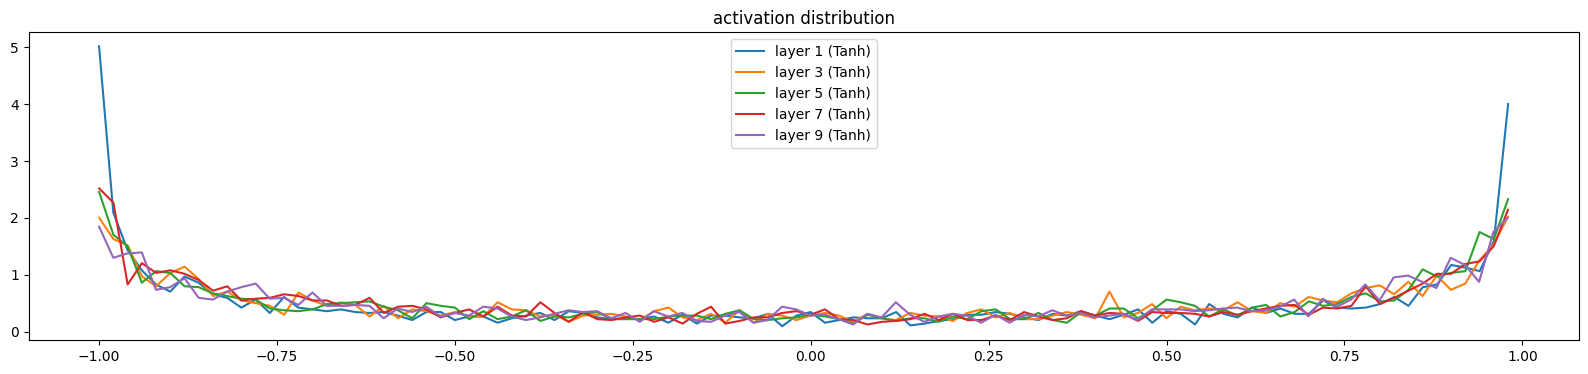

In [40]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%" % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('activation distribution')

The first layer is fairly saturated, and every layer after it stabilizes. If we had more layers, it would layer at std: 0.65, saturated: 5%. This is because the gain is set to $\frac{2}{3}$.

When the gain is $1$, the saturation will shrink to 0 and the further layers will shrink to 0. The reason for this is because if we had distributions with std of 1, it will get squashed, so a gain is needed to fight against it.

A gain of $3$ would create super high activations, making the tanh layer very saturated.

layer 1 (      Tanh): mean +0.000024, std 3.353992e-03
layer 3 (      Tanh): mean +0.000012, std 3.157344e-03
layer 5 (      Tanh): mean -0.000004, std 2.925863e-03
layer 7 (      Tanh): mean +0.000036, std 2.715700e-03
layer 9 (      Tanh): mean +0.000020, std 2.308167e-03


Text(0.5, 1.0, 'gradient distribution')

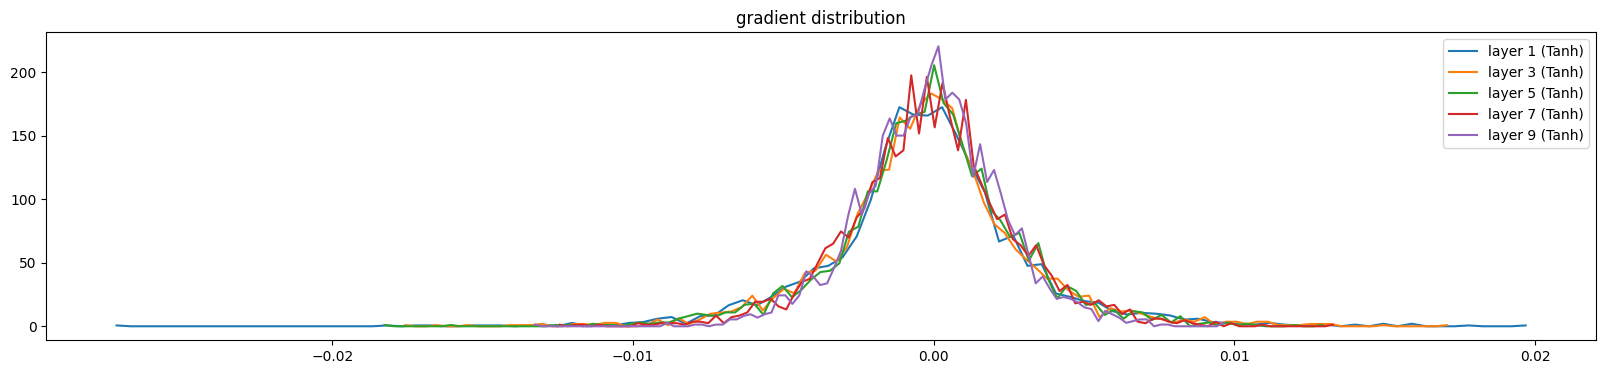

In [41]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e" % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('gradient distribution')

We're looking for all the layers to have roughly the same gradient; nothing is shrinking or exploding.

Setting the gain to something low would cause the activations to shrink to 0 the higher the layer, and the gradients expand out.

Similarly, if our gain was too high, the gradients increase the higher the layer.

weight   (27, 10) | mean +0.000980 | std 1.189171e-02 | grad:data ratio 1.189149e-02
weight  (30, 100) | mean +0.000118 | std 1.005291e-02 | grad:data ratio 3.214556e-02
weight (100, 100) | mean +0.000033 | std 7.821213e-03 | grad:data ratio 4.653363e-02
weight (100, 100) | mean -0.000107 | std 6.655620e-03 | grad:data ratio 3.925851e-02
weight (100, 100) | mean -0.000017 | std 6.086040e-03 | grad:data ratio 3.605768e-02
weight (100, 100) | mean -0.000077 | std 5.075620e-03 | grad:data ratio 3.015269e-02
weight  (100, 27) | mean +0.000000 | std 2.056585e-02 | grad:data ratio 2.909911e-01


Text(0.5, 1.0, 'weights gradient distribution')

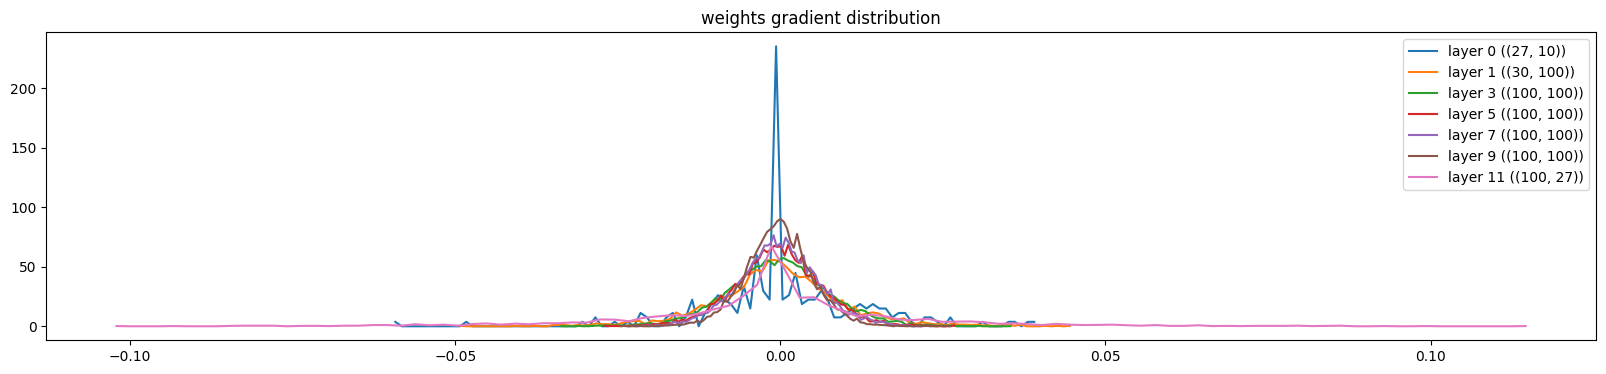

In [42]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s | mean %+f | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')

plt.legend(legends);
plt.title('weights gradient distribution')

The gradient to data ratio is important because you take the learning rate times the gradient to update the data. If the gradient has too large of a magnitude compared to the numbers in data, you would be in trouble.

In this case, we are fine except for the last layer. In the simple SGD setup, we would be training the last layer about 10 times faster at initialization. 

This kind of fixes itself after some training

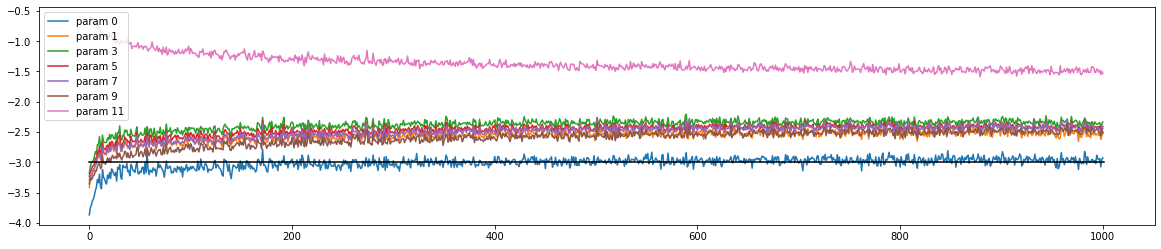

In [88]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

This is saying the updates to the weights should be ~ 1000 less than the weight themselves. The last layer is higher intentionally because we wanted to make the last layer less confident for the softmax. This made the values in the tensor way too low, but this stabilizes over time.

We want to make sure that it's not too much over 1e-3. If it is below 1e-3, then the parameters are not training fast enough.

Getting neural nets to train without modern techniques was a balancing act, as you have to be careful with your initialization.

## Batch Norm

Now, we can be less accurate with our gain as BatchNorm is more robust to these changes. However, this will change the learning to data ratio. We might need to tune the learning rate.

In [44]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1 # Gamma is the scale of the Batch Norm
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


You can get very similar results placing the Batch Norm before and after the non-linearity.

In [45]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_grad

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break  # AFTER_DEBUG: would take out to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'activation distribution')

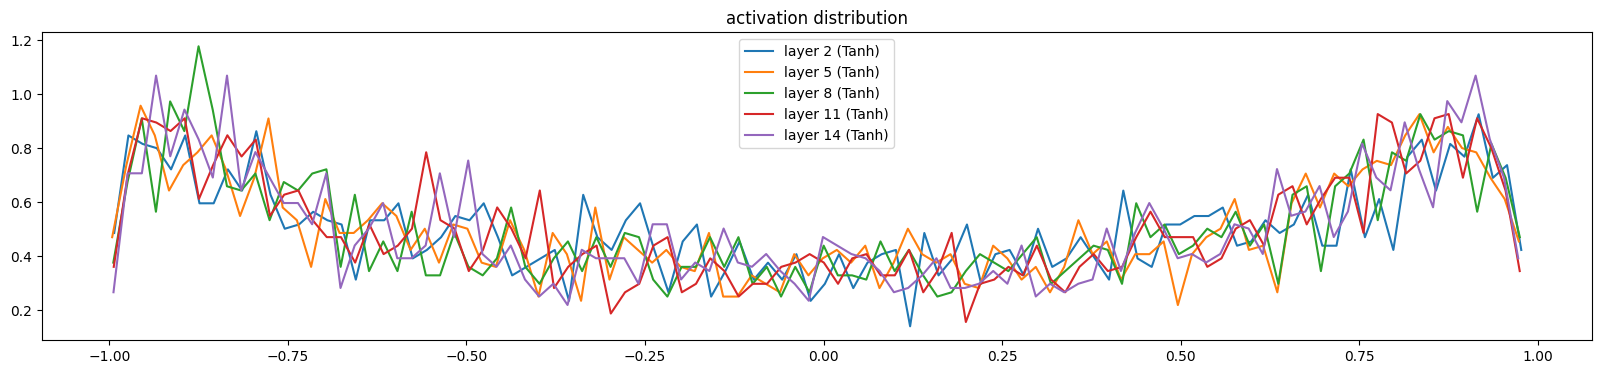

In [46]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%" % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.682954e-03
layer 5 (      Tanh): mean -0.000000, std 3.262609e-03
layer 8 (      Tanh): mean +0.000000, std 2.973730e-03
layer 11 (      Tanh): mean -0.000000, std 2.741111e-03
layer 14 (      Tanh): mean +0.000000, std 2.584294e-03


Text(0.5, 1.0, 'gradient distribution')

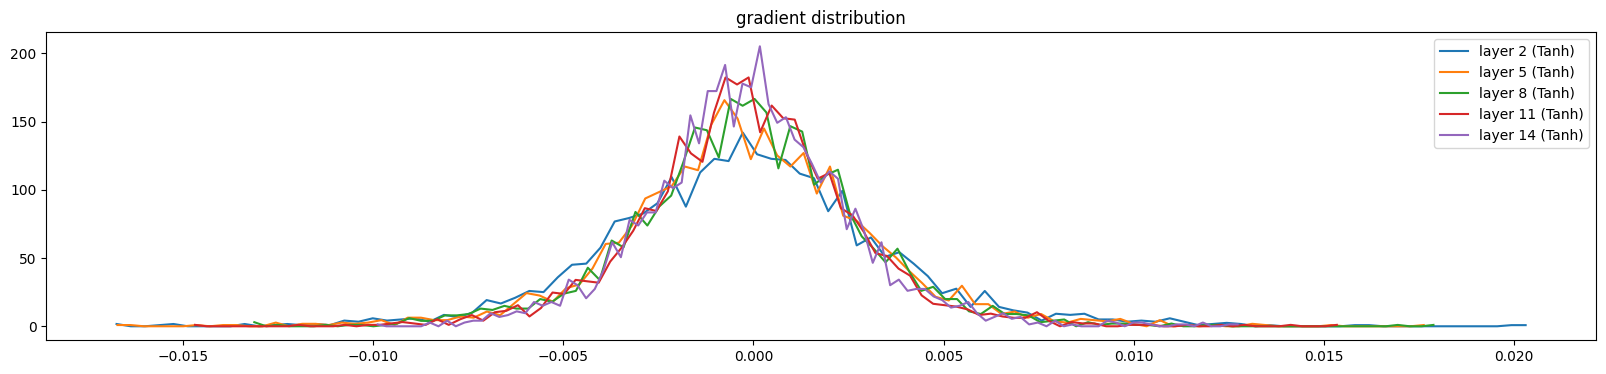

In [47]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e" % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.019887e-02 | grad:data ratio 1.018847e-02
weight  (30, 100) | mean +0.000092 | std 8.238431e-03 | grad:data ratio 2.635839e-02
weight (100, 100) | mean +0.000031 | std 7.318114e-03 | grad:data ratio 4.377145e-02
weight (100, 100) | mean -0.000019 | std 6.662026e-03 | grad:data ratio 3.949897e-02
weight (100, 100) | mean -0.000019 | std 5.821517e-03 | grad:data ratio 3.468162e-02
weight (100, 100) | mean +0.000053 | std 5.445298e-03 | grad:data ratio 3.243368e-02
weight  (100, 27) | mean -0.000165 | std 1.046845e-02 | grad:data ratio 6.281266e-02


Text(0.5, 1.0, 'weights gradient distribution')

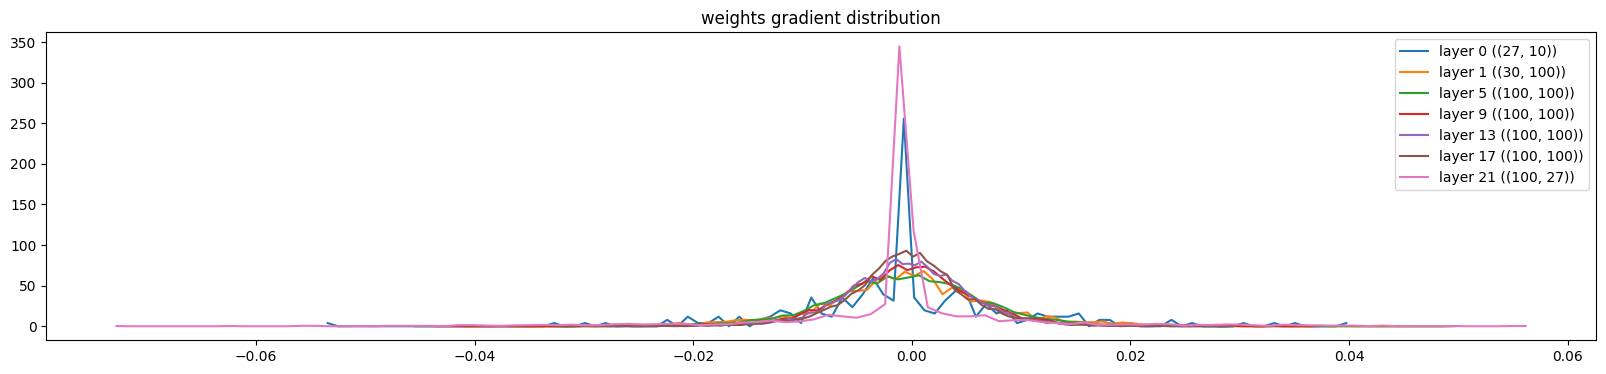

In [48]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s | mean %+f | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')

plt.legend(legends);
plt.title('weights gradient distribution')

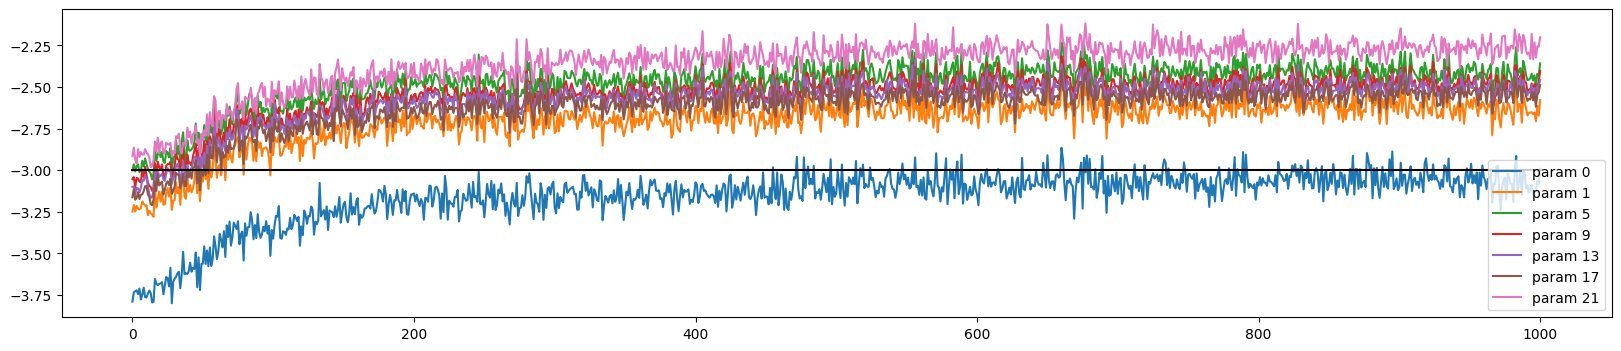

In [49]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);